In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = ROOT / 'notebooks' / 'data' / 'synthetic_sales_transactions.csv'
MODEL_DIR = ROOT / 'backend' / 'ml' / 'models' / 'saved'
OUT_DIR = ROOT / 'notebooks' / 'outputs' / 'model_validation'
MODEL_PATH = MODEL_DIR / 'xgboost_sales.pkl'
METRICS_PATH = OUT_DIR / 'evaluation_metrics.json'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = [
    'product_id', 'dow', 'month', 'quarter', 'doy', 'year',
    'lag_1', 'lag_7', 'lag_14', 'lag_30', 'roll_7', 'roll_30'
]

print(f'Data: {DATA_PATH}')
print(f'Model save path: {MODEL_PATH}')
print(f'Output images dir: {OUT_DIR}')

Data: D:\Project\Project VI\BI_Platform\notebooks\data\synthetic_sales_transactions.csv
Model save path: D:\Project\Project VI\BI_Platform\backend\ml\models\saved\xgboost_sales.pkl
Output images dir: D:\Project\Project VI\BI_Platform\notebooks\outputs\model_validation


In [2]:
raw = pd.read_csv(DATA_PATH)
raw['sale_date'] = pd.to_datetime(raw['sale_date'])

daily = (
    raw.groupby(['product_id', pd.Grouper(key='sale_date', freq='D')], as_index=False)['quantity']
       .sum()
       .rename(columns={'sale_date': 'ds', 'quantity': 'y'})
)

# Build complete daily timelines per product (fill missing days with zero units).
frames = []
for pid, g in daily.groupby('product_id'):
    idx = pd.date_range(g['ds'].min(), g['ds'].max(), freq='D')
    f = g.set_index('ds').reindex(idx).fillna({'y': 0.0}).rename_axis('ds').reset_index()
    f['product_id'] = int(pid)
    frames.append(f[['product_id', 'ds', 'y']])

data = pd.concat(frames, ignore_index=True).sort_values(['product_id', 'ds']).reset_index(drop=True)
print('Rows:', len(data), '| Products:', data['product_id'].nunique())
data.head()

Rows: 53984 | Products: 60


,product_id,ds,y
0,1001,2023-10-03,9.0
1,1001,2023-10-04,2.0
2,1001,2023-10-05,17.0
3,1001,2023-10-06,8.0
4,1001,2023-10-07,6.0


In [3]:
df = data.copy()
df['dow'] = df['ds'].dt.dayofweek
df['month'] = df['ds'].dt.month
df['quarter'] = df['ds'].dt.quarter
df['doy'] = df['ds'].dt.dayofyear
df['year'] = df['ds'].dt.year

grp = df.groupby('product_id', group_keys=False)
df['lag_1'] = grp['y'].shift(1)
df['lag_7'] = grp['y'].shift(7)
df['lag_14'] = grp['y'].shift(14)
df['lag_30'] = grp['y'].shift(30)
df['roll_7'] = grp['y'].shift(1).rolling(7).mean().reset_index(level=0, drop=True)
df['roll_30'] = grp['y'].shift(1).rolling(30).mean().reset_index(level=0, drop=True)
df = df.dropna().reset_index(drop=True)

df = df.sort_values('ds').reset_index(drop=True)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train, y_train = train_df[FEATURES], train_df['y']
X_test, y_test = test_df[FEATURES], test_df['y']

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train ratio:', round(len(train_df) / len(df), 3), '| Test ratio:', round(len(test_df) / len(df), 3))

Train rows: 41747
Test rows: 10437
Train ratio: 0.8 | Test ratio: 0.2


In [4]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

pred = model.predict(X_test)
mae = float(mean_absolute_error(y_test, pred))
rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
r2 = float(r2_score(y_test, pred))

metrics = {
    'mae': round(mae, 4),
    'rmse': round(rmse, 4),
    'r2': round(r2, 6),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
}

joblib.dump(model, MODEL_PATH)
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('Saved model:', MODEL_PATH)
print('Saved metrics:', METRICS_PATH)
metrics

Saved model: D:\Project\Project VI\BI_Platform\backend\ml\models\saved\xgboost_sales.pkl
Saved metrics: D:\Project\Project VI\BI_Platform\notebooks\outputs\model_validation\evaluation_metrics.json


{'mae': 3.7927,
 'rmse': 4.914,
 'r2': -0.031345,
 'train_rows': 41747,
 'test_rows': 10437}

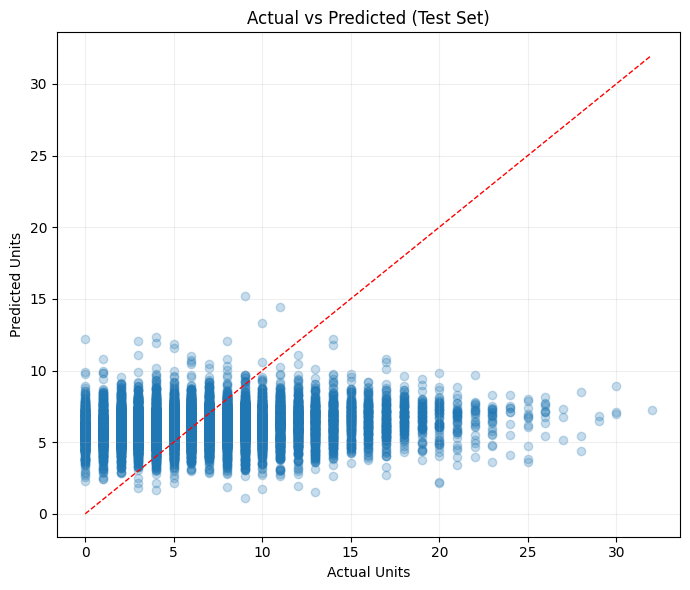

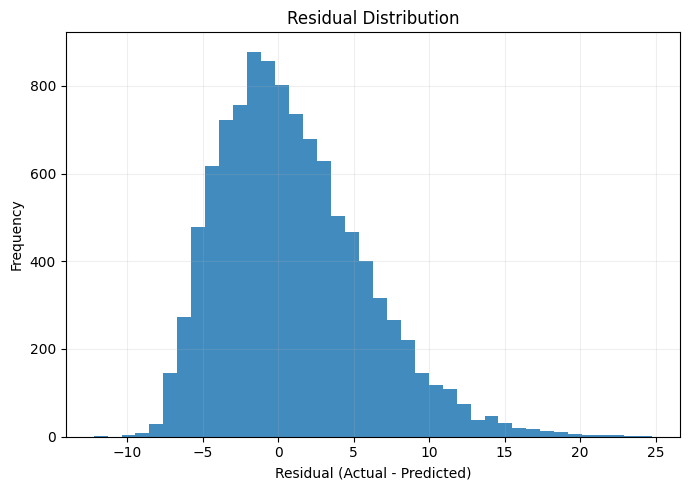

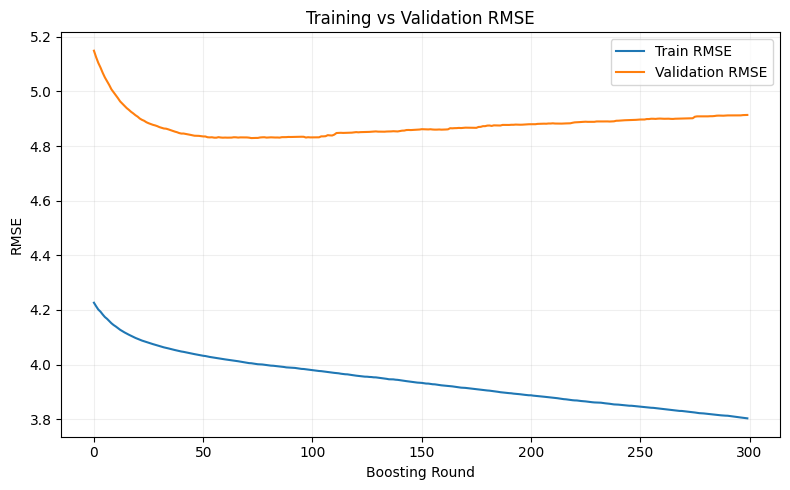

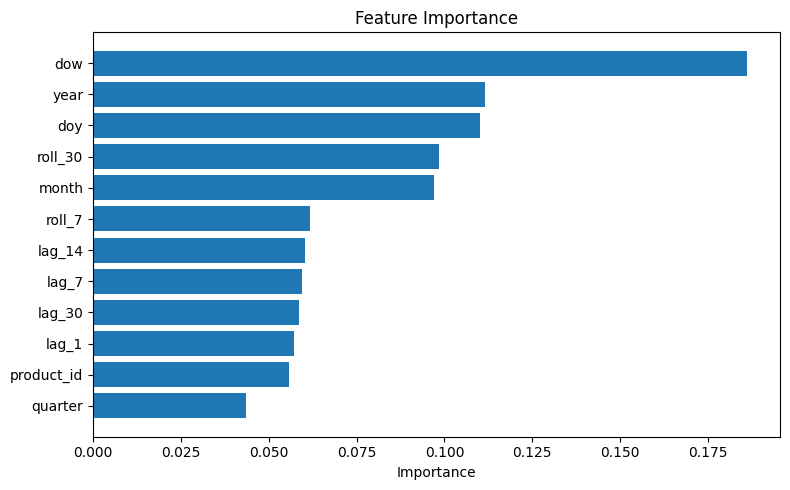

Generated files:
- actual_vs_predicted.png
- feature_importance.png
- residual_distribution.png
- validation_rmse_curve.png


In [5]:
# 1) Actual vs Predicted scatter
plt.figure(figsize=(7, 6))
plt.scatter(y_test.values, pred, alpha=0.25)
diag_min = min(float(y_test.min()), float(pred.min()))
diag_max = max(float(y_test.max()), float(pred.max()))
plt.plot([diag_min, diag_max], [diag_min, diag_max], 'r--', linewidth=1)
plt.xlabel('Actual Units')
plt.ylabel('Predicted Units')
plt.title('Actual vs Predicted (Test Set)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'actual_vs_predicted.png', dpi=160)
plt.show()

# 2) Residual distribution
residuals = y_test.values - pred
plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=40, alpha=0.85)
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'residual_distribution.png', dpi=160)
plt.show()

# 3) Validation RMSE curve from training logs
evals = model.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(evals['validation_0']['rmse'], label='Train RMSE')
plt.plot(evals['validation_1']['rmse'], label='Validation RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('Training vs Validation RMSE')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'validation_rmse_curve.png', dpi=160)
plt.show()

# 4) Feature importance
importance = model.feature_importances_
imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importance}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 5))
plt.barh(imp_df['feature'], imp_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=160)
plt.show()

print('Generated files:')
for p in sorted(OUT_DIR.glob('*.png')):
    print('-', p.name)

In [6]:
# Optional: Next-month product-wise unit forecast from the trained model
future_days = pd.date_range(start=(pd.Timestamp.today().normalize() + pd.offsets.MonthBegin(1)), periods=30, freq='D')

histories = {pid: grp.sort_values('ds')['y'].tolist() for pid, grp in data.groupby('product_id')}
product_forecast = []
for pid in sorted(histories.keys()):
    hist = [float(x) for x in histories[pid]]
    total = 0.0
    for day in future_days:
        lag1 = hist[-1]
        lag7 = hist[-7] if len(hist) >= 7 else hist[-1]
        lag14 = hist[-14] if len(hist) >= 14 else hist[-1]
        lag30 = hist[-30] if len(hist) >= 30 else hist[-1]
        roll7 = float(np.mean(hist[-7:])) if len(hist) >= 7 else float(np.mean(hist))
        roll30 = float(np.mean(hist[-30:])) if len(hist) >= 30 else float(np.mean(hist))

        row = pd.DataFrame([{
            'product_id': pid,
            'dow': day.dayofweek,
            'month': day.month,
            'quarter': ((day.month - 1) // 3) + 1,
            'doy': day.dayofyear,
            'year': day.year,
            'lag_1': lag1,
            'lag_7': lag7,
            'lag_14': lag14,
            'lag_30': lag30,
            'roll_7': roll7,
            'roll_30': roll30,
        }])
        pred_u = max(float(model.predict(row)[0]), 0.0)
        hist.append(pred_u)
        total += pred_u

    product_forecast.append({'product_id': int(pid), 'predicted_units_next_30d': round(total, 2)})

pred_df = pd.DataFrame(product_forecast).sort_values('predicted_units_next_30d', ascending=False).reset_index(drop=True)
pred_df.head(20)

,product_id,predicted_units_next_30d
0,1001,177.80
1,1002,172.39
2,1060,171.37
3,1003,168.31
4,1006,166.41
5,1004,166.31
6,1047,165.82
7,1024,165.06
8,1021,164.87
9,1049,164.41
